In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib.pyplot as plt

import sspspace

# Random Encoding

In [4]:
xs = np.linspace(-10,10,1000).reshape((-1,1))
rand_encoder = sspspace.RandomSSPSpace(domain_dim=2, ssp_dim=1024*2, length_scale=1/np.pi, rng=np.random.default_rng(0))
rand_phase_matrix = rand_encoder.phase_matrix
rand_phase_matrix[100,0] = 5

# try:
#     rand_encoder = sspspace.SSPEncoder(phase_matrix=rand_phase_matrix)
# except Exception as ex:
#     if ex.args[0] == "Phase Matrix is not conjugate-symmetric":
#         pass
#     else:
#         print(f"Error in Expected Behaviour")
#         raise 

ego_grad = rand_encoder.gradient(rand_encoder.encode([5,5], allo=True), allo=True)
allo_grad = rand_encoder.gradient(rand_encoder.encode([5,5], allo=False), allo=False)
assert np.linalg.norm(ego_grad - allo_grad) < 0.02, f"Unexpectedly Large Difference in Ego and Allo gradients: l-2 error={np.linalg.norm(ego_grad - allo_grad)}"


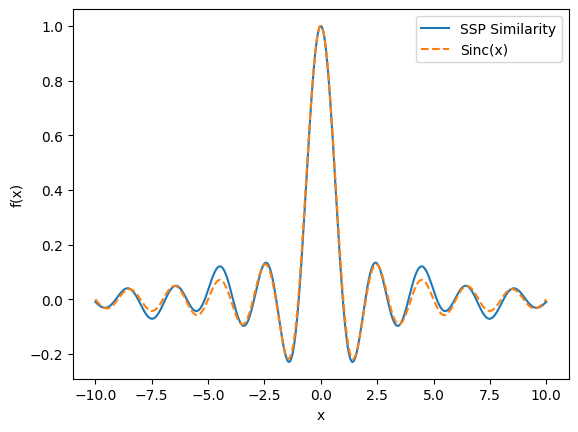

In [3]:
xs = np.linspace(-10,10,1000).reshape((-1,1))
rand_encoder = sspspace.RandomSSPSpace(domain_dim=1, ssp_dim=1024*2, length_scale=1/np.pi)

query_xs_ssp = rand_encoder.encode(xs)
origin_ssp = rand_encoder.encode([[0]])

sims = query_xs_ssp | origin_ssp
true_sims = np.sinc(xs)

error = np.mean(np.power(sims-true_sims, 2))

assert error < 0.01, f'Expected error of 0.01, got {error}'
plt.plot(xs, sims, label='SSP Similarity')
plt.plot(xs, true_sims, ls='--', label='Sinc(x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

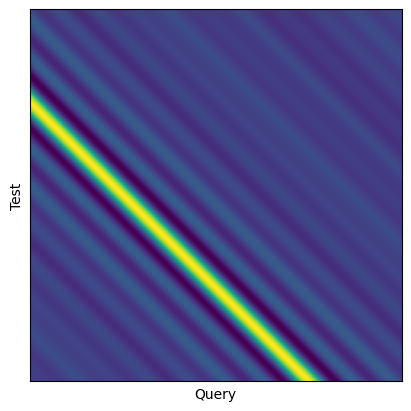

In [4]:
test_xs_ssp = rand_encoder.encode(np.linspace(-5,15,1000).reshape((-1,1)))
sims_2d = query_xs_ssp | test_xs_ssp
plt.matshow(sims_2d)
plt.xlabel('Query')
plt.ylabel('Test')
plt.xticks([]);
plt.yticks([]);

In [5]:
a = np.array([[0]])
b = np.array([[5]])

a_ssp = rand_encoder.encode(a)
b_ssp = rand_encoder.encode(b)

print(test_xs_ssp[:10] | b_ssp)
print(np.sinc(np.pi * 5))

[[-0.00932846]
 [-0.01092865]
 [-0.01251169]
 [-0.01407082]
 [-0.01559931]
 [-0.01709044]
 [-0.0185376 ]
 [-0.01993423]
 [-0.02127392]
 [-0.0225504 ]]
-0.016091030896682075


Note: use @ sign for similarity?

# Cyclic SSPs

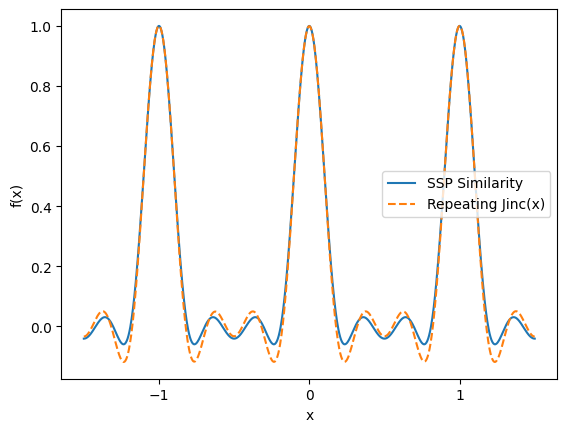

In [6]:
xs = np.linspace(-1.5,1.5,1000).reshape((-1,1))
cyc_encoder = sspspace.CyclicSSPSpace(ssp_dim=2048, domain_dim=1, band_scale=0.3, period=1, kernel="jinc")

query_xs_ssp = cyc_encoder.encode(xs)
origin_ssp = cyc_encoder.encode([[0]])

from scipy.special import jv
sims = query_xs_ssp | origin_ssp

true_sims = 2 * jv(1, 2 * np.pi * xs / 0.3) / (2 * np.pi * xs / 0.3)
for i in np.arange(1,10):
    true_sims += 2 * jv(1, 2 * np.pi * (xs + i) / 0.3) / (2 * np.pi * (xs + i) / 0.3)
    true_sims += 2 * jv(1, 2 * np.pi * (xs - i) / 0.3) / (2 * np.pi * (xs - i) / 0.3)
true_sims /= true_sims.max()
error = np.mean(np.power(sims-true_sims, 2))

assert error < 0.01, f'Expected error of 0.01, got {error}'
plt.plot(xs, sims, label='SSP Similarity')
plt.plot(xs, true_sims, ls='--', label='Repeating Jinc(x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.xticks([-1, 0, 1])
plt.legend()


# Hexagonal SSPs

Note: check Nengo tools for even sampling of rotations in domain dim > 3

Note: add functionality to add grid sampling, code to return samples as ssps.

Note: add similarity plots of ssps over domain. 

Note: add similarities as probabilities

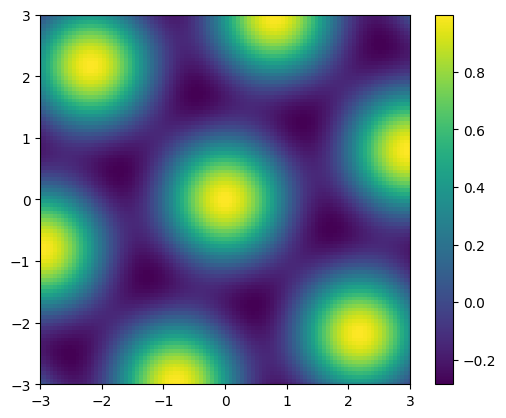

In [7]:
xs = np.linspace(-3,3,100).reshape((-1,1))
ys = np.linspace(-3,3,100).reshape((-1,1))

X, Y = np.meshgrid(xs, ys)
xys = np.vstack((X.flatten(), Y.flatten())).T

hex_encoder = sspspace.HexagonalSSPSpace(domain_dim=2, n_rotates=1, n_scales=1, kernel='gaussian')
# print(hex_encoder.phase_matrix)
hex_encoder.update_lengthscale(0.5)

query_xys_ssp = hex_encoder.encode(xys)
origin_ssp = hex_encoder.encode([[0,0]])

sims = query_xys_ssp | origin_ssp
square_sims = sims.reshape((ys.shape[0], xs.shape[0]))

f, axs = plt.subplot_mosaic([["A"]])
ax = axs["A"]
im = ax.pcolormesh(X, Y, sims.reshape(X.shape), vmin=sims.min(), vmax=sims.max())
ax.set_aspect('equal', 'box')

ax.set_xlim(-3,3)
ax.set_ylim(-3,3)
cbar = ax.figure.colorbar(im, ax=ax)#, ticks=[0,0.2,0.4, 0.6, 0.8, 1.0])

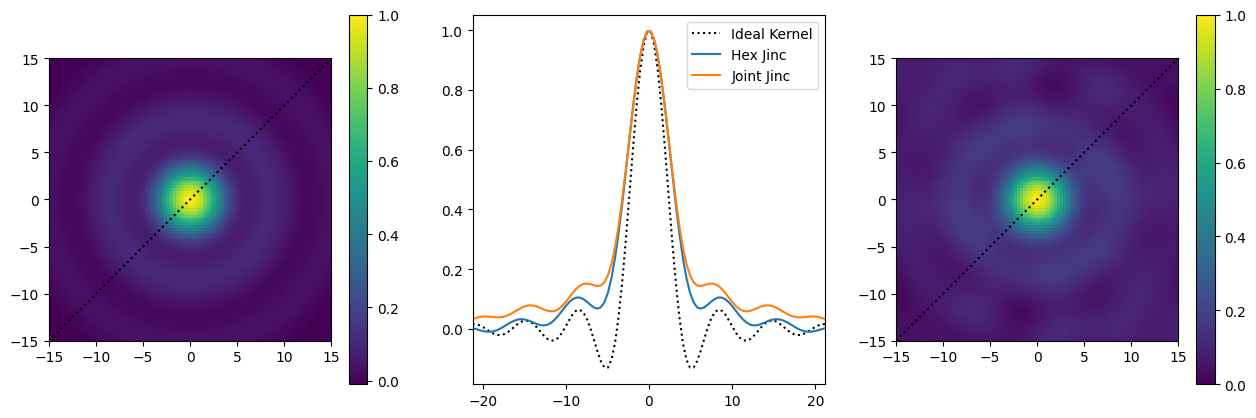

In [8]:
import scipy
h = 15
xs = np.linspace(-h,h,100).reshape((-1,1))
ys = np.linspace(-h,h,100).reshape((-1,1))

X, Y = np.meshgrid(xs, ys)
xys = np.vstack((X.flatten(), Y.flatten())).T

n_rotates = 55
n_scales = 9
hex_encoder = sspspace.HexagonalSSPSpace(domain_dim=2, n_rotates=n_rotates, n_scales=n_scales, kernel='jinc', length_scale=1)
joint_encoder = sspspace.JointSSPSpace(domain_dim=2, ssp_dim=6 * n_rotates * n_scales + 1, kernel="jinc", length_scale=1)

f, axs = plt.subplot_mosaic([["A", "B", "C"]])
f.subplots_adjust(right=2)
R = np.array([np.sqrt(X[0,i] ** 2 + Y[i,0] ** 2) * np.sign(X[0,i]) for i in range(100)])
# axs["B"].plot(R, np.sinc(R * 3 / np.pi), 'k:', label="Ideal Kernel")
axs["B"].plot(R, 2 * scipy.special.j1(R) / R, 'k:', label="Ideal Kernel")
for space, ax, label in zip([hex_encoder, joint_encoder], [axs["A"], axs["C"]], ["Hex Jinc", "Joint Jinc"]):
    query_xys_ssp = space.encode(xys, allo=True)
    origin_ssp = space.encode([[0,0]], allo=True)

    sims = query_xys_ssp | origin_ssp
    square_sims = sims.reshape((ys.shape[0], xs.shape[0]))

    axs["B"].plot(R, [square_sims[i,i] for i in range(100)], label=label)

    im = ax.pcolormesh(X, Y, sims.reshape(X.shape), vmin=sims.min() if sims.min() < 0 else 0, vmax=sims.max() if sims.max() > 1 else 1)
    ax.plot(X[0,:], X[0,:], 'k:')
    ax.set_aspect('equal', 'box')

    ax.set_xlim(-h,h)
    ax.set_ylim(-h,h)
    cbar = ax.figure.colorbar(im, ax=ax, ticks=[0,0.2,0.4, 0.6, 0.8, 1.0])

axs["B"].set_xlim(R.min(), R.max())
axs["B"].legend()

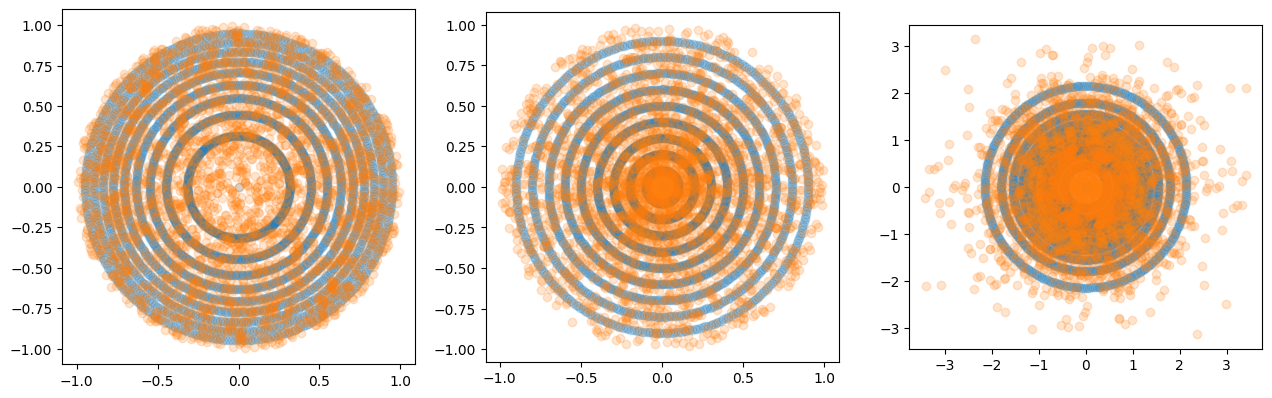

In [9]:
f, axs = plt.subplot_mosaic([["A", "B", "C"]])
f.subplots_adjust(right=2)

for (kernel, ax) in zip(["sinc", "jinc", "gaussian"], [axs["A"], axs["B"], axs["C"]]):
    hex_encoder = sspspace.HexagonalSSPSpace(domain_dim=2, n_rotates=n_rotates, n_scales=n_scales, kernel=kernel)
    joint_encoder = sspspace.JointSSPSpace(domain_dim=2, ssp_dim=6 * n_rotates * n_scales + 1, kernel=kernel)

    ax.scatter(hex_encoder.phase_matrix[:,0], hex_encoder.phase_matrix[:,1], alpha=0.2)
    ax.scatter(joint_encoder.phase_matrix[:,0], joint_encoder.phase_matrix[:,1], alpha=0.2)
    ax.set_aspect("equal")

# Bundling

Note: make bundling consistent with what numpy does (change assert to only check number of ssp features)


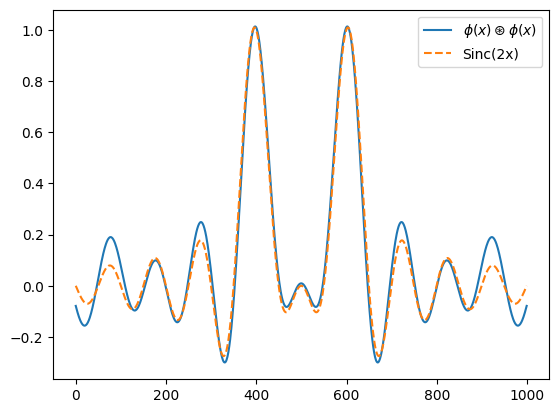

In [10]:
xs = np.linspace(-10,10,1000).reshape((-1,1))
rand_encoder = sspspace.RandomSSPSpace(domain_dim=1,ssp_dim=1024*2, length_scale=1/np.pi)
 
query_xs_ssp = rand_encoder.encode(xs)
origin_ssp = rand_encoder.encode([[-2]]) + rand_encoder.encode([[2]])
 
sims = query_xs_ssp | origin_ssp
true_sims = np.sinc(xs-2) + np.sinc(xs+2)
error = np.mean(np.power(sims-true_sims, 2))

plt.plot(sims, label=r'$\phi(x)\circledast\phi(x)$')
plt.plot(true_sims, ls='--', label='Sinc(2x)')
plt.legend()

# Binding

Assumes we are binding the same number of vectors together, pairwise.

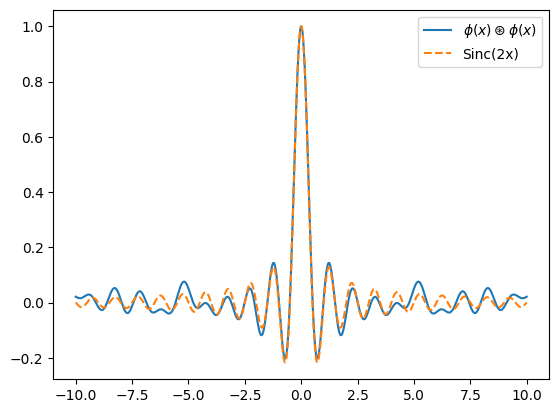

In [11]:
xs = np.linspace(-10,10,1000).reshape((-1,1))
rand_encoder = sspspace.RandomSSPSpace(domain_dim=1,ssp_dim=1024*2, length_scale=1/np.pi)
 
query_xs_ssp = rand_encoder.encode(xs)
origin_ssp = rand_encoder.encode([[0]])
 
bound_self = query_xs_ssp * query_xs_ssp
sims = bound_self | origin_ssp
true_sims = np.sinc(2 * xs)
error = np.mean(np.power(sims-true_sims, 2))

plt.plot(xs, sims, label=r'$\phi(x)\circledast\phi(x)$')
plt.plot(xs, true_sims, ls='--', label='Sinc(2x)')
plt.legend()

# Inverting

<StemContainer object of 3 artists>

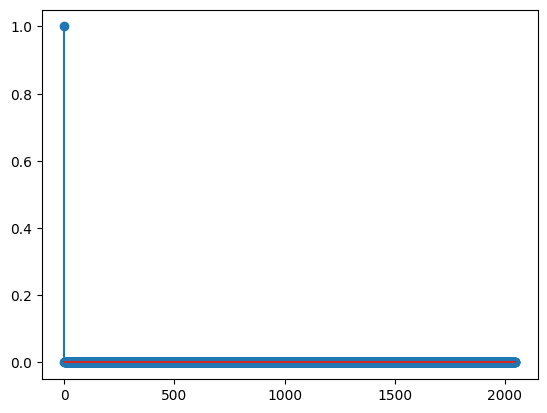

In [12]:
rand_encoder = sspspace.RandomSSPSpace(domain_dim=1,ssp_dim=1024*2, length_scale=1/np.pi)
 
origin_ssp = rand_encoder.encode([[5]])
origin_inv_ssp = ~origin_ssp
 
bound_vec = origin_inv_ssp * origin_ssp

plt.stem(np.arange(bound_vec.shape[1]), bound_vec.T)

# Component Sizes

Biasing of the SSP embedding encourages all entries to follow the same distribution by forcing the manifold away from the identity vector.

Text(0.5, 1.0, 'Cosine Distribution')

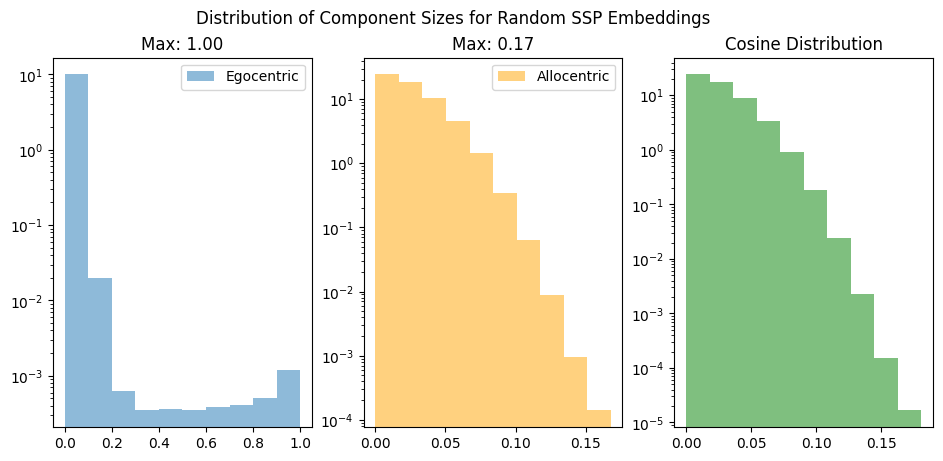

In [54]:
from nengo.dists import CosineSimilarity

n = 100
N = 100
D = 1024
comps_ego = np.zeros((n, N, D))
comps_allo = np.zeros((n, N, D))
for i in range(n):
    rand_encoder = sspspace.CyclicSSPSpace(domain_dim=1, ssp_dim=D, period=2)#, length_scale=.01)
    ego_encs = rand_encoder.encode(np.atleast_2d(np.random.uniform(-10,10,N)).T)
    allo_encs = rand_encoder.encode(np.atleast_2d(np.random.uniform(-10,10,N)).T, allo=True)
    comps_ego[i,:,:] = np.abs(ego_encs)
    comps_allo[i,:,:] = np.abs(allo_encs)
    # comps_ego[i,:,0] = np.mean(comps_ego[i,:,1:])

f, (ax1, ax2, ax3) = plt.subplots(1,3)
f.subplots_adjust(right=1.5)
f.suptitle("Distribution of Component Sizes for Random SSP Embeddings",x=0.75)
ax1.hist(comps_ego.reshape(-1), alpha=0.5, density=True, log=True);
ax1.set_title(f"Max: {comps_ego.max():.2f}")
ax1.legend(["Egocentric"])
ax2.hist(comps_allo.reshape(-1), alpha=0.5, density=True, log=True, color='orange');
ax2.set_title(f"Max: {comps_allo.max():.2f}")
ax2.legend(["Allocentric"])
ax3.hist(np.abs(CosineSimilarity(D+2).sample(10000000)), density=True, alpha=0.5, log=True, color='green')
ax3.set_title("Cosine Distribution")


# Decode SSPs

In [36]:
bounds = np.array([[-10,10]])
ssp_encoder = sspspace.RandomSSPSpace(domain_dim=1,ssp_dim=128, length_scale=.1)
ssp_decoder, training_history = sspspace.train_decoder_net_tf(ssp_encoder, bounds, 
                                    n_training_pts=200000, # number of points sample from domain
                                    hidden_units=[8], # list of neurons in dense hidden layers
                                    learning_rate=1e-3, # learning rate for Adam
                                    n_epochs=20, # Max epochs
                                    patience=3, # patience for early stopping
                                    verbose=True, # print tensorflow training nonsense.
                                    allo=True
                                )

/home/jchouin/Development/sspspace_dev/sspspace/sspspace/util.py:9: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  u_sample_points = sampler.random(num_samples)


Epoch 1/20
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 3s 483us/step - loss: 0.5549 - val_loss: 6.9431e-04
Epoch 2/20
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 3s 505us/step - loss: 0.0018 - val_loss: 0.0017
Epoch 3/20
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 2s 425us/step - loss: 0.0014 - val_loss: 0.0016
Epoch 4/20
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 2s 440us/step - loss: 9.8512e-04 - val_loss: 3.3088e-04
Epoch 5/20
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 2s 369us/step - loss: 9.3727e-04 - val_loss: 0.0021
Epoch 6/20
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 2s 386us/step - loss: 7.7282e-04 - val_loss: 0.0032
Epoch 7/20
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 3s 465us/step - loss: 7.2614e-04 - val_loss: 0.0025
Epoch 8/20
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 2s 388us/step - loss: 5.8958e-04 - val_loss: 1.8310e-04
Epoch 9/20
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 2s 385us/step - loss: 5.7210e-04 - val_loss: 5.4931e-05
Epoch 10/20
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 2s 374us/step - loss: 4.9265e-04 - val_loss: 8.4642e-05
Epoch 11/20
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 3s 449us

In [45]:
xs = np.random.uniform(low=bounds[0,0], high=bounds[0,1], size=(100,1))
enc_ssps = ssp_encoder.encode(xs, allo=True)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
3.19913887285213e-07 0.0005656093062222483
0.02833473210775992 0.05986552159697191


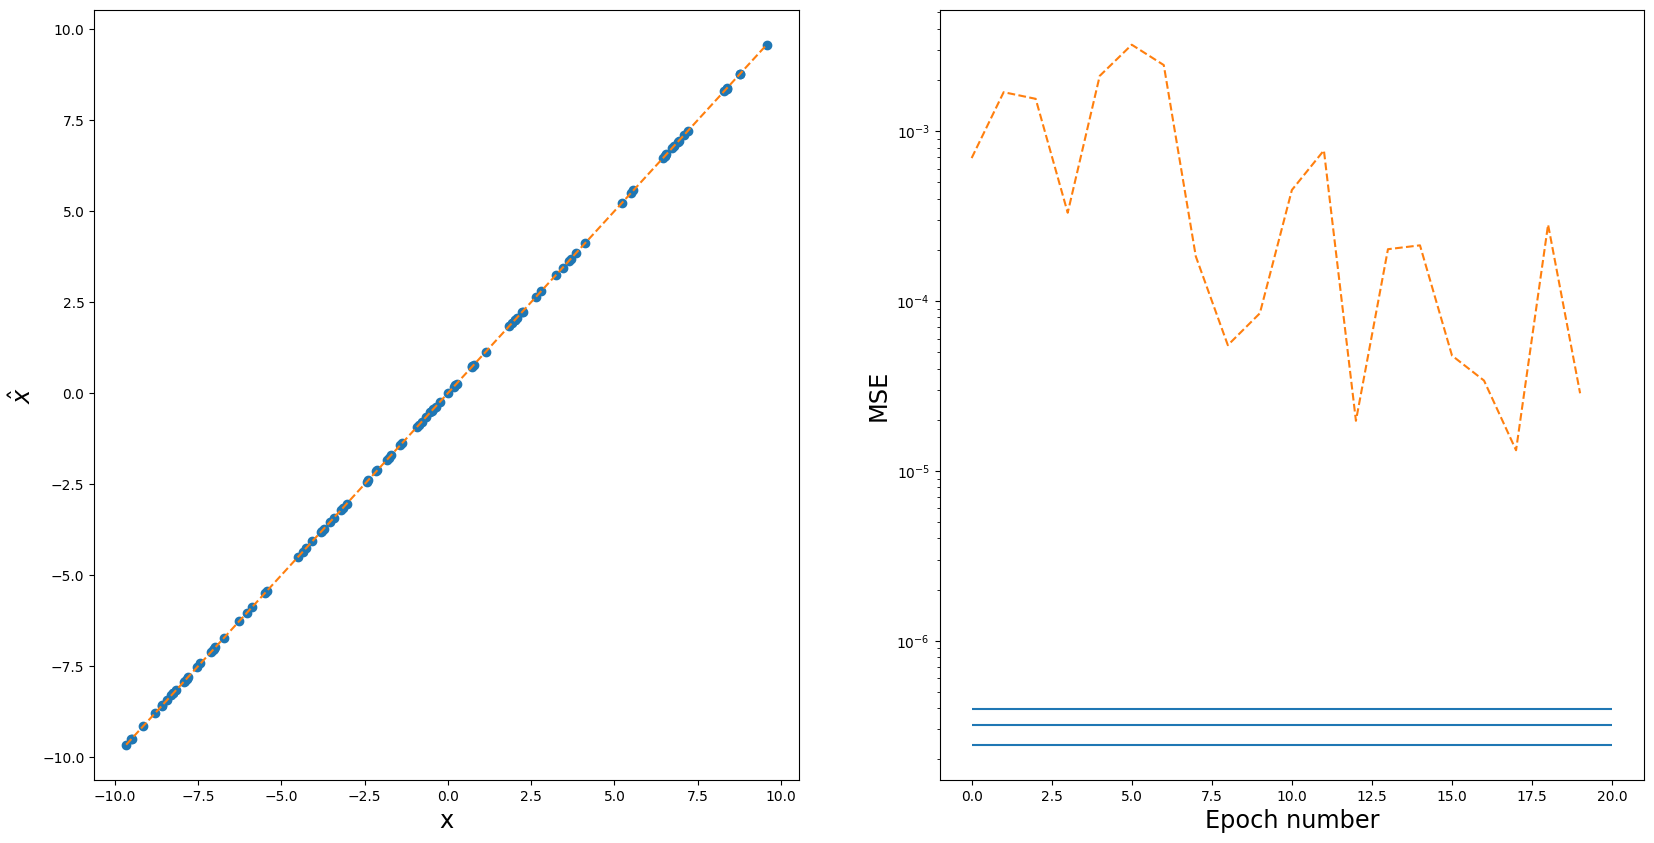

In [46]:
dec_xs = ssp_decoder.decode(enc_ssps, allo=True)

errors = np.abs(dec_xs - xs)**2
mu_err = np.mean(errors)
ste_err = np.std(errors) / np.sqrt(xs.shape[0])

max_epochs = len(training_history.history['val_loss'])

plt.figure(figsize=(20,10))
plt.subplot(1,2,1)
plt.scatter(xs, dec_xs)
plt.plot([xs.min(), xs.max()],[xs.min(), xs.max()], ls='--', c='tab:orange')
plt.xlabel('x', fontsize='xx-large')
plt.ylabel(r'$\hat{x}$', fontsize='xx-large')

plt.subplot(1,2,2)
plt.plot(training_history.history['val_loss'], label='Validation loss', ls='--', c='tab:orange')
plt.hlines(y=[mu_err - 1.96 * ste_err, mu_err, mu_err + 1.96 * ste_err], xmin=0, xmax=max_epochs, label='')
plt.yscale('log')
plt.ylabel('MSE', fontsize='xx-large')
plt.xlabel('Epoch number', fontsize='xx-large')
print(mu_err, np.sqrt(mu_err))
print(np.mean(training_history.history['loss']), np.mean(np.sqrt(training_history.history['loss'])))